Technically, retrieving the data set should be the first step but I'll go ahead and set the imports first. Just because.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Then we pull in the data from our local machine

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Market Data USDJPY before 2024.05.01.csv to Market Data USDJPY before 2024.05.01.csv


In [3]:
filename = list(uploaded.keys())[0]

data = pd.read_csv(filename)
data.tail(5)

,Time,Open,High,Low,Close,Volume
95841,2024.04.30 19:00:00,157.539,157.568,157.429,157.457,2648
95842,2024.04.30 20:00:00,157.456,157.640,157.437,157.562,1921
95843,2024.04.30 21:00:00,157.561,157.727,157.542,157.691,2010
95844,2024.04.30 22:00:00,157.691,157.756,157.668,157.703,2148
95845,2024.04.30 23:00:00,157.704,157.841,157.703,157.823,1391


95845, we'll trim it down to 50,000 by deleting all rows after 50,000

In [4]:
data = data[::-1]
# Reduce the dataset to the first 50,000 rows
data = data.head(50000)

print(len(data))

50000


In [5]:
data.describe()

,Open,High,Low,Close,Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,32.196692,32.224418,32.167570,32.197914,1614.338260
std,59.527048,59.577205,59.474088,59.529217,8824.442472
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,159.393000,160.204000,159.297000,159.392000,364868.000000


Scaling the dataset. I'm still on the line about doing this.

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Open', 'High', 'Low', 'Close', 'Volume']])

# Create a new DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=['Open', 'High', 'Low', 'Close', 'Volume'])


The below functions will create a window through which our model will look through to make predictions.

In [7]:
import numpy as np
def prepare_data(data, n_steps):
    X, y = [], []
    for i in range(len(data)-n_steps-1):
        a = data[i:(i+n_steps), 0]
        X.append(a)
        y.append(data[i + n_steps, 0])
    return np.array(X), np.array(y)


We'll go with a window size of 50 rows since we have 50,000 rows.

In [8]:
n_steps = 50
X, y = prepare_data(scaled_data, n_steps)

Next we'll give the data a shape that fits in the model.
The data takes the shape [samples, time steps, features]


In [9]:
X = X.reshape(X.shape[0], X.shape[1], 1)

Split the data into training and testing sets

In [10]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

Now the fun part. We train our model.

In [11]:
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense

Initialize the LSTM model

In [12]:
# LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(n_steps, 1)))
model.add(LSTM(50))
model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile the model

In [13]:
model.compile(optimizer='adam', loss='mse')

Train the model

I reduced epochs for faster execution. The accuracy will suffer for it but it's either that or I'll have to keep this running for hours.

In [14]:
model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 63s 47ms/step - loss: 0.0043
Epoch 2/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - loss: 1.0387e-04
Epoch 3/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - loss: 8.8034e-05
Epoch 4/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - loss: 8.0721e-05
Epoch 5/5
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - loss: 7.1256e-05


Make predictions with the model we just ran.

In [15]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

1249/1249 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


Revert the Scaling back to the actual values

In [16]:
train_predict = scaler.inverse_transform(np.concatenate((train_predict, np.zeros((len(train_predict),4))),axis=1))[:,0]
y_train = scaler.inverse_transform(np.concatenate((y_train.reshape(-1,1), np.zeros((len(y_train),4))),axis=1))[:,0]

test_predict = scaler.inverse_transform(np.concatenate((test_predict, np.zeros((len(test_predict),4))),axis=1))[:,0]
y_test = scaler.inverse_transform(np.concatenate((y_test.reshape(-1,1), np.zeros((len(y_test),4))),axis=1))[:,0]


Evaluate the model by looking the fruits of it's labor

In [21]:
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

rmse_train = math.sqrt(mean_squared_error(y_train, train_predict))
rmse_test = math.sqrt(mean_squared_error(y_test, test_predict))
print('Train RMSE: %.3f' % rmse_train)
print('Test RMSE: %.3f' % rmse_test)

Train RMSE: 0.836
Test RMSE: 0.050


And here's a visual representations of Plotting actual vs. predicted values for training data


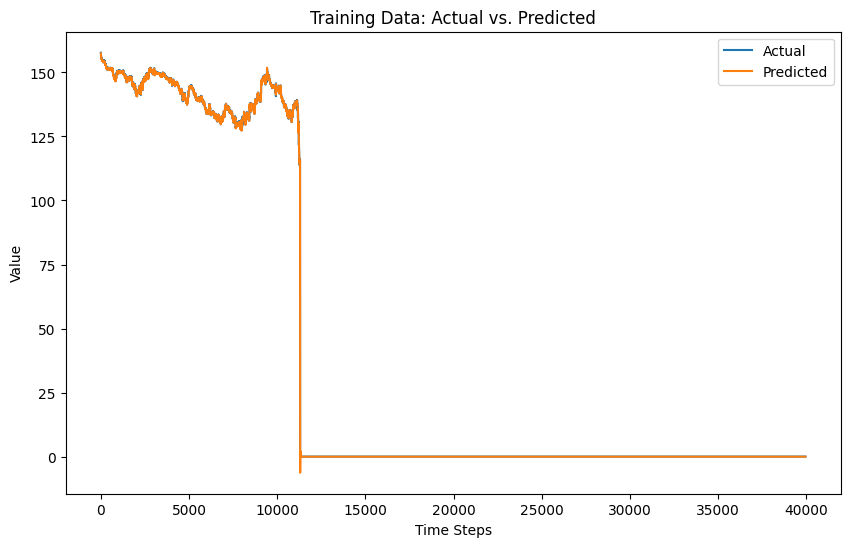

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(y_train, label='Actual')
plt.plot(train_predict, label='Predicted')
plt.title('Training Data: Actual vs. Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()

And one for actual vs. predicted values for testing data


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual')
plt.plot(test_predict, label='Predicted')
plt.title('Testing Data: Actual vs. Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()